In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO DISCOUNT RECIPIENTS
print("\n🎯 FILTERING TO DISCOUNT RECIPIENTS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with discount
has_discount = df_quotes.groupby('numero_compte')['mt_remise_exceptionnelle_ht'].apply(
    lambda x: (x < 0).any()  # Negative = discount
)

discount_recipient_ids = has_discount[has_discount].index.tolist()

# Filter data
df_quotes_discount = df_quotes[df_quotes['numero_compte'].isin(discount_recipient_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Discount recipients: {len(discount_recipient_ids):,}")
print(f"Quotes: {len(df_quotes_discount):,}")

# Save to file
df_quotes_discount.to_csv('cleaned_quote_data_discount.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_discount.csv")


🎯 FILTERING TO DISCOUNT RECIPIENTS
Original customers: 25,716
Discount recipients: 8,119
Quotes: 12,980

✅ Saved to cleaned_quote_data_discount.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_discount.csv')


📊 Original quote data: 12,980 quotes from 8,119 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 8,119, Quotes: 12,464
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 8,119 customers | 48.4% converters
⏱️  Execution time: 3.7 seconds
⚠️  3.7s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 12,980
  Total customers: 8,119
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 8,119
    Quotes after filter: 12,495
⚡ Processing 8,119 customers with sequence features...
  Processed 5,000/8,119 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 8,119
  Converters: 3,930 (48.4%)
  Features created: 21
  Product column used: regro

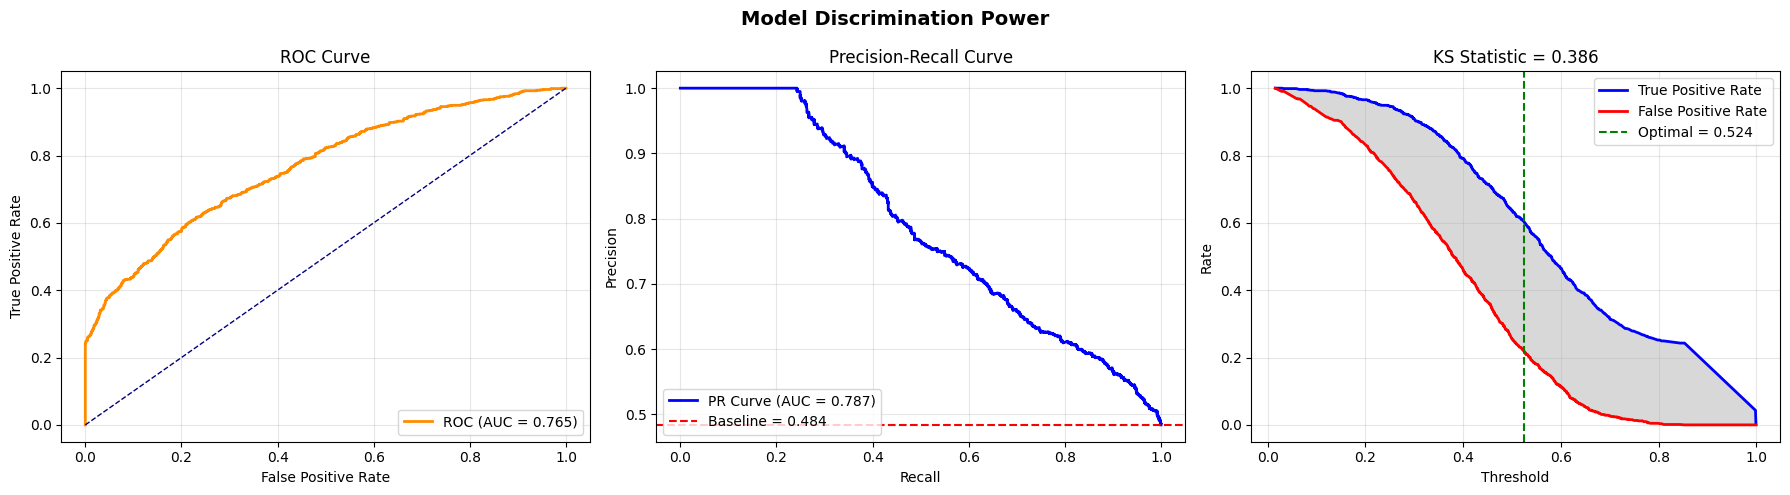

• ROC-AUC: 0.7653
• PR-AUC: 0.7873
• KS Statistic: 0.386 (MODERATE discrimination)
• Optimal Threshold: 0.524

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.998
Decile 10 mean prob: 0.120


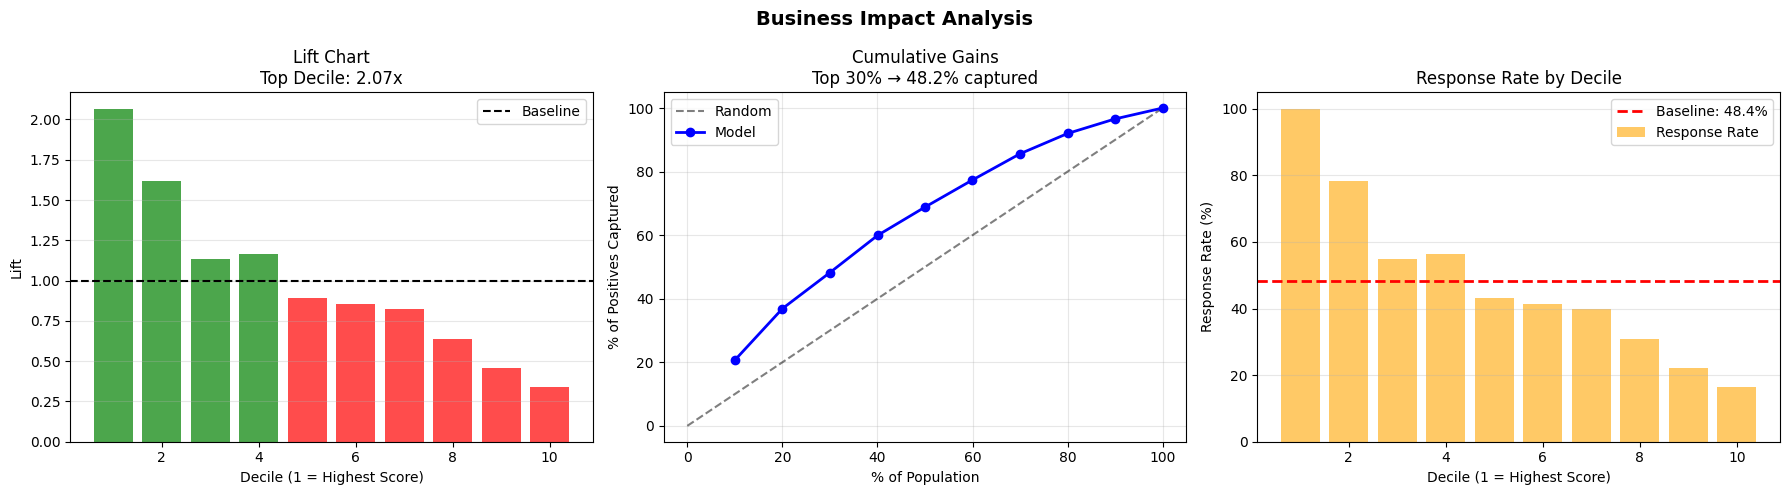

• Top Decile Lift: 0.34x
• Top 30% captures: 48.2% of positives
• Baseline response rate: 48.4%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


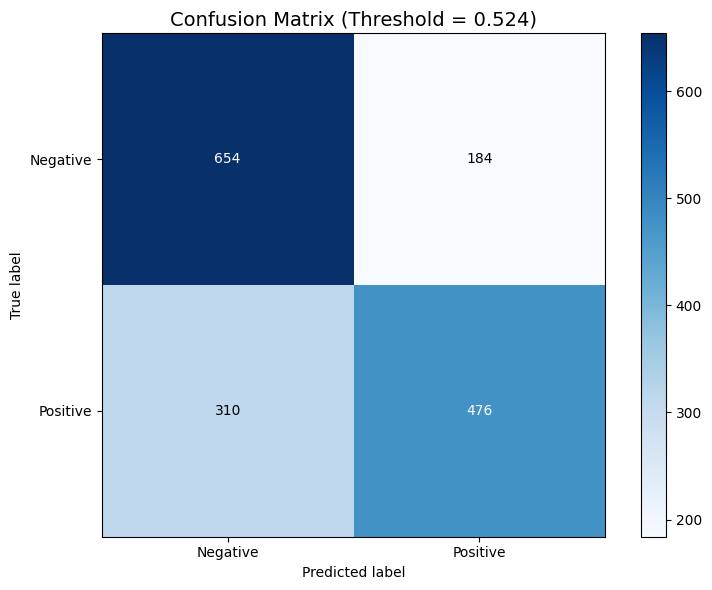

At threshold 0.524:
• Accuracy: 0.696
• Precision: 0.721
• Recall: 0.606
• F1-Score: 0.658
• True Positives: 476
• False Positives: 184
• True Negatives: 654
• False Negatives: 310

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.386 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.34x better than random
   Coverage: Top 30% → 48.2% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7653 (Excellent if >0.8)
   PR-AUC: 0.7873 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.524
   Precision at threshold: 0.721
   Recall at threshold: 0.606

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                            feature  importance
178         quote_consistency_score    0.094587
167                is_quick_decider    0.038067
249          price_x_sophistication    0.021609
62                  mean_complexity    0.021189
54          equipment_variety_count    0.017423
303                max_price_bin_10    0.016713
38            

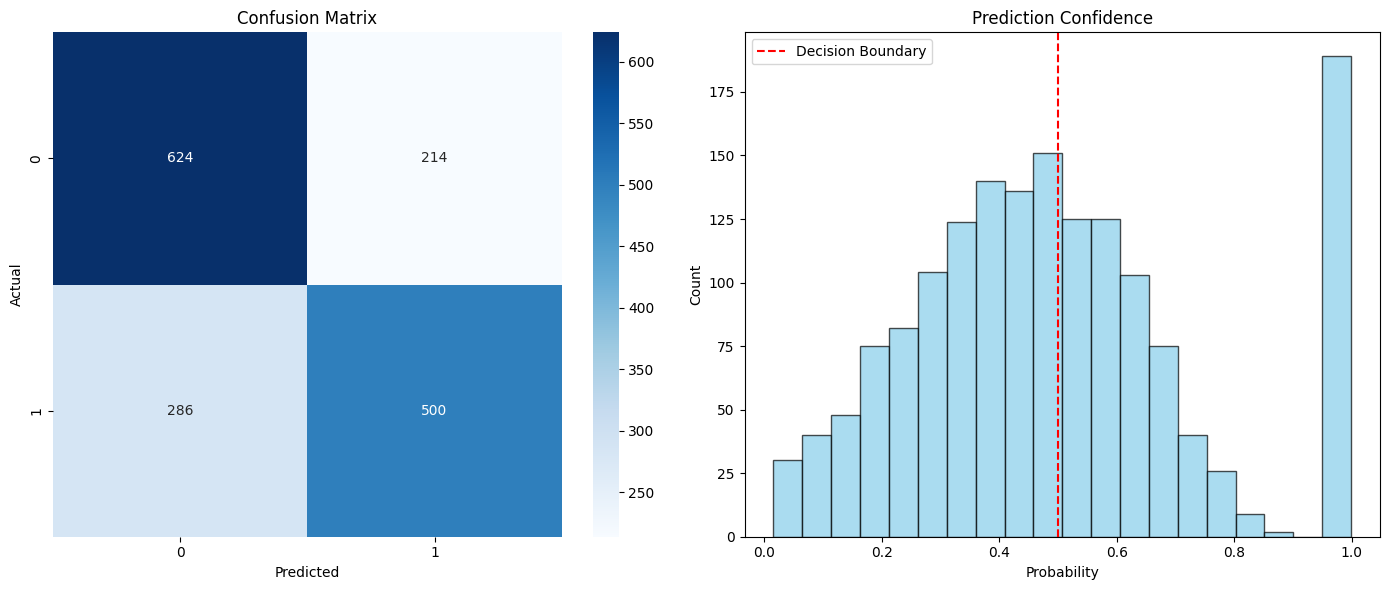

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])